# Exploratory Data Analysis - Trade Exception Prediction

This notebook explores the synthetic trading data to understand patterns and exceptions.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [32]:
# Load data
data_path = Path('../data/trades_synthetic.csv')
df = pd.read_csv(data_path)
print(f"Data shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Data shape: (1000, 13)

First few rows:


,trade_id,timestamp,counterparty,instrument_type,notional_amount,trade_price,settlement_date,market_volatility,counterparty_risk_score,execution_speed_ms,price_deviation_pct,trade_size_percentile,is_exception
0,T00001,2024-10-29 22:00:00,Bank_D,FX,687000.935872,144.459614,2024-10-31 22:00:00,0.304636,0.469473,533.328619,0.053843,4.961274,0
1,T00002,2024-02-05 20:00:00,Bank_D,BOND,395360.218444,132.802393,2024-02-07 20:00:00,0.053432,0.220952,51.151997,0.041981,49.954542,1
2,T00003,2024-08-12 14:00:00,Bank_E,BOND,66963.470020,146.487224,2024-08-14 14:00:00,0.380904,0.365984,101.680464,0.059382,25.225941,0
3,T00004,2024-08-04 07:00:00,Bank_F,EQUITY,97368.941789,142.026343,2024-08-06 07:00:00,0.278339,0.161614,216.946861,0.067953,91.106553,0
4,T00005,2024-08-26 22:00:00,Bank_E,FX,670020.485222,120.739096,2024-08-28 22:00:00,0.337341,0.165850,55.041312,0.035583,39.849249,0


In [ ]:
  print("=== DATA INFO ===")
  print(f"Shape: {df.shape}")
  print(f"\nColumns: {df.columns.tolist()}")
  print(f"\nColumn names (first 10):")
  for i, col in enumerate(df.columns[:10]):
      print(f"  {i}: {col}")
  print(f"\nData types:\n{df.dtypes}")
  print(f"\nFirst few rows:\n{df.head()}")

In [33]:
# Data info
print("Data types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Data types:
trade_id                    object
timestamp                   object
counterparty                object
instrument_type             object
notional_amount            float64
trade_price                float64
settlement_date             object
market_volatility          float64
counterparty_risk_score    float64
execution_speed_ms         float64
price_deviation_pct        float64
trade_size_percentile      float64
is_exception                 int64
dtype: object

Missing values:
trade_id                   0
timestamp                  0
counterparty               0
instrument_type            0
notional_amount            0
trade_price                0
settlement_date            0
market_volatility          0
counterparty_risk_score    0
execution_speed_ms         0
price_deviation_pct        0
trade_size_percentile      0
is_exception               0
dtype: int64


In [34]:
df.columns

Index(['trade_id', 'timestamp', 'counterparty', 'instrument_type',
       'notional_amount', 'trade_price', 'settlement_date',
       'market_volatility', 'counterparty_risk_score', 'execution_speed_ms',
       'price_deviation_pct', 'trade_size_percentile', 'is_exception'],
      dtype='object')

Exception Distribution:
is_exception
0    700
1    300
Name: count, dtype: int64

Exception Rate: 30.00%


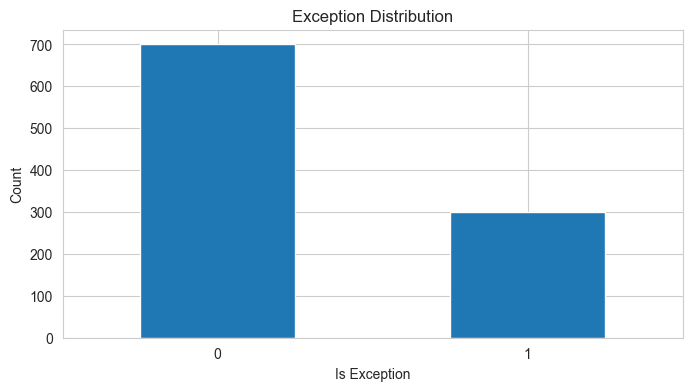

In [35]:
# Exception distribution
exception_counts = df['is_exception'].value_counts()
print(f"Exception Distribution:")
print(exception_counts)
print(f"\nException Rate: {df['is_exception'].mean():.2%}")

plt.figure(figsize=(8, 4))
exception_counts.plot(kind='bar')
plt.title('Exception Distribution')
plt.ylabel('Count')
plt.xlabel('Is Exception')
plt.xticks(rotation=0)
plt.show()

In [36]:
# Statistical summary
df.describe()

,notional_amount,trade_price,market_volatility,counterparty_risk_score,execution_speed_ms,price_deviation_pct,trade_size_percentile,is_exception
count,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.368631e+06,124.627905,0.281117,0.288507,100.157304,0.306343,49.463182,0.300000
std,3.541214e+06,17.484992,0.159346,0.161724,102.097409,0.305232,28.435237,0.458487
min,2.751164e+03,95.011192,0.005937,0.011663,0.024070,0.002160,0.017552,0.000000
25%,1.658030e+05,109.403024,0.153430,0.163741,28.526785,0.091795,25.663624,0.000000
50%,4.829733e+05,124.544940,0.265475,0.269452,71.007838,0.202513,48.852600,0.000000
75%,1.325374e+06,140.151803,0.386502,0.390734,137.469490,0.417303,72.464321,1.000000
max,8.378937e+07,154.857369,0.914731,0.794799,913.957166,1.903400,99.736618,1.000000


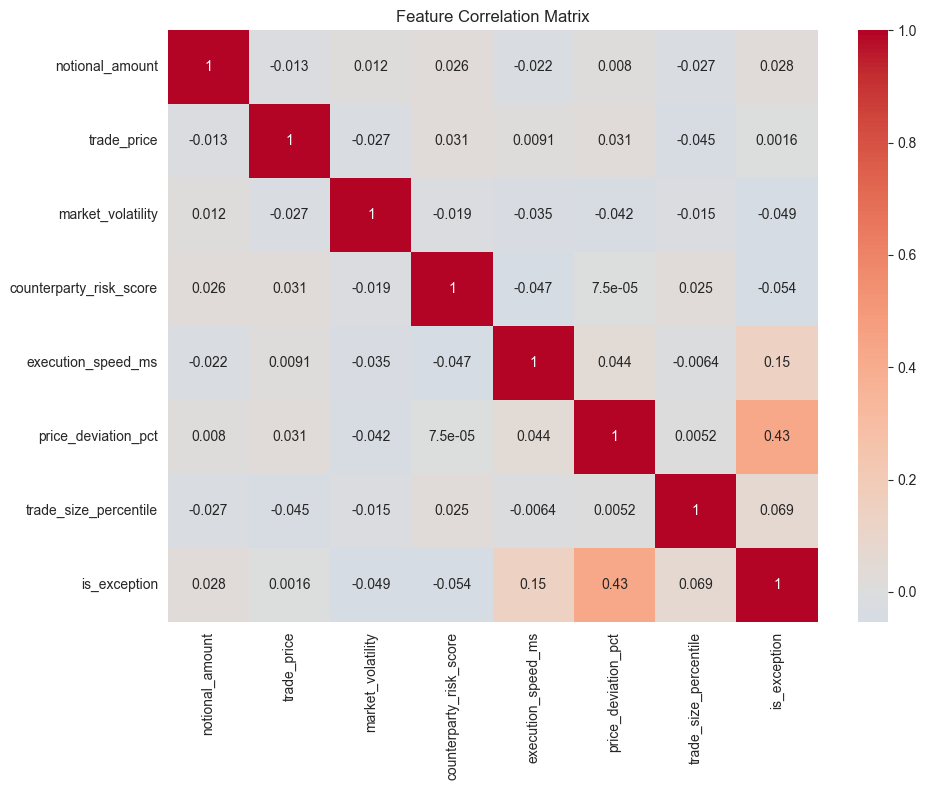

In [37]:
# Feature correlations
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [38]:
# Exception vs normal trades comparison
exception_analysis = df.groupby('is_exception')[numeric_cols].mean()
print("Mean values by exception status:")
print(exception_analysis)

Mean values by exception status:
              notional_amount  trade_price  market_volatility  \
is_exception                                                    
0                1.303585e+06   124.609131           0.286253   
1                1.520403e+06   124.671712           0.269134   

              counterparty_risk_score  execution_speed_ms  \
is_exception                                                
0                            0.294205           90.455551   
1                            0.275211          122.794728   

              price_deviation_pct  trade_size_percentile  is_exception  
is_exception                                                            
0                        0.220661              48.170218           0.0  
1                        0.506268              52.480097           1.0  
